In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/s-and-p500-options-spy-implied-volatility-2019-24/spy_options_data_23.json
/kaggle/input/s-and-p500-options-spy-implied-volatility-2019-24/spy_options_data_24.json
/kaggle/input/s-and-p500-options-spy-implied-volatility-2019-24/spy_options_data_22.json
/kaggle/input/s-and-p500-options-spy-implied-volatility-2019-24/spy_options_data_20.json
/kaggle/input/s-and-p500-options-spy-implied-volatility-2019-24/spy_options_data_19.json
/kaggle/input/s-and-p500-options-spy-implied-volatility-2019-24/spy_options_data_21.json


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import os
from datetime import datetime
import requests
import json
from decimal import Decimal, getcontext
from multiprocessing import Pool
import dask.dataframe as dd
from dask.multiprocessing import get
from dask import delayed
from sklearn.linear_model import LinearRegression

In [3]:
path = '/kaggle/input/s-and-p500-options-spy-implied-volatility-2019-24/spy_options_data_19.json'
data = {}
with open(path, 'r') as f:
    data = json.load(f)
print(len(data))
print(data[0][0])

251
{'contractID': 'SPY190102C00100000', 'symbol': 'SPY', 'expiration': '2019-01-02', 'strike': '100.00', 'type': 'call', 'last': '0.00', 'mark': '150.24', 'bid': '149.02', 'bid_size': '310', 'ask': '151.45', 'ask_size': '10', 'volume': '0', 'open_interest': '0', 'date': '2019-01-02', 'implied_volatility': '6.45519', 'delta': '0.99803', 'gamma': '0.00007', 'theta': '-0.27069', 'vega': '0.00082', 'rho': '0.00272'}


In [4]:
class preprocessData:
    """
    create a dataframe from the json file with required features
    """
    def __init__(self, json_path):
        self.json_path = json_path
        getcontext().prec = 8

    def _get_stats(self, obj):
        exp_date = datetime.strptime(obj['expiration'], '%Y-%m-%d')
        curr_date = datetime.strptime(obj['date'], '%Y-%m-%d')
        tte = (exp_date - curr_date).days
        tau = Decimal(tte) / Decimal(365)
        delta = abs(float(obj['delta']))
        if(delta==1):
            delta = 0.999
        elif(delta==0):
            delta = 0.001
        IV = np.float64(obj['implied_volatility'])
        sigma = IV
        q = Decimal('0.01')
        N_inv = norm.ppf(delta * float(np.exp(float(q) * float(tau))))
        sigma = Decimal(sigma)
        m = (Decimal('0.5') * sigma**2 * tau) + (Decimal(N_inv) * sigma * Decimal(tau).sqrt())
        current_date = curr_date.strftime('%Y-%m-%d')
        expiry_date = exp_date.strftime('%Y-%m-%d')
        return [current_date, expiry_date, tte, tau, delta, IV, sigma, N_inv, m]
    
    @delayed
    def delayed_stats(self, obj):
        return self._get_stats(obj)
    
    def fit(self):
        with open(self.json_path, 'r') as f:
            data = json.load(f)
        
        if len(data) == 0:
            logging.error("No data found in the json file")
            return None

        # results = [self.delayed_stats(d) for d in data]
        # results = dd.from_delayed(results)
        # df = results.compute(scheduler='processes')

        # df = dd.from_pandas(df, npartitions=4)
        # merge all sublists in data into one list
        data = [item for sublist in data for item in sublist]
        result = []
        for d in data:
            result.append(self._get_stats(d))
        df = pd.DataFrame(result)
        df.columns = ['date', 'expiry_date', 'tte', 'tau', 'delta', 'IV', 'sigma', 'N_inv', 'm']
        df = df.groupby(['date', 'm', 'tau', 'delta'])['IV'].mean().reset_index()
        df = df[df.IV < 1]
        return df
    
class fitSurface:
    """
    columns = ['date','m','tau','delta','IV']
    fit a surface to the IV data with a discrete grid of m and tau
    following Dumas et al. (1998)
    """
    def __init__(self, df):
        self.df = df
        self.grid_tau = [x/365 for x in [10,30,60,91,122,152,182,273,365,547,730]]
        self.grid_m = [np.log(m) for m in [0.6, 0.8, 0.9, 0.95, 0.975, 1, 1.025, 1.05, 1.1, 1.2, 1.3, 1.5, 1.75, 2]]
        try:
            self.dates = self.df['date'].unique()
        except:
            raise ValueError('Input dataframe must have a "date" column')
        
    def _fit_and_get_model_params(self):
        self.df['m_squared'] = self.df['m']**2
        self.df['tau_squared'] = self.df['tau']**2
        self.df['m_tau'] = self.df['m'] * self.df['tau']
        X = self.df[['m', 'tau', 'm_squared', 'tau_squared', 'm_tau']]
        y = self.df['IV']
        model = LinearRegression()
        model.fit(X, y)
        return model
    
    def _predict(self, tau, m, model):
        m_squared = m**2
        tau_squared = tau**2
        m_tau = m * tau
        input_data = pd.DataFrame({'m': [m], 'tau': [tau], 'm_squared': [m_squared], 'tau_squared': [tau_squared], 'm_tau': [m_tau]})
        iv_ = max(0.01, model.predict(input_data)[0])
        return iv_
    
    def fit(self):
        """Fit surface separately for each date"""
        predicted_iv = pd.DataFrame()
        
        for date in self.dates:
            # Get data for this date only
            date_df = self.df[self.df['date'] == date].copy()
            
            # Fit model for this date
            date_df['m_squared'] = date_df['m']**2
            date_df['tau_squared'] = date_df['tau']**2
            date_df['m_tau'] = date_df['m'] * date_df['tau']
            X = date_df[['m', 'tau', 'm_squared', 'tau_squared', 'm_tau']]
            y = date_df['IV']
            
            model = LinearRegression()
            model.fit(X, y)
            
            # Predict for grid points
            for tau in self.grid_tau:
                for m in self.grid_m:
                    iv = self._predict(tau, m, model)
                    new_row = pd.DataFrame({
                        'date': [date], 
                        'tau': [tau], 
                        'm': [m], 
                        'IV': [iv]
                    })
                    predicted_iv = pd.concat([predicted_iv, new_row])
            
            if len(predicted_iv) % 1000 == 0:  # Progress indicator
                print(f"Processed {len(predicted_iv)} points...")
                        
        predicted_iv.columns = ['date', 'tau', 'm', 'IV']
        return predicted_iv

In [5]:
json_path = "/kaggle/input/s-and-p500-options-spy-implied-volatility-2019-24/spy_options_data_19.json"
preprocess = preprocessData(json_path)
csv_save_path = "./predicted_iv19.csv"
df = preprocess.fit()
fit = fitSurface(df)
predicted_iv = fit.fit()
predicted_iv.to_csv(csv_save_path, index=False)

In [6]:
df.head()

,date,m,tau,delta,IV
0,2019-01-02,-2.3438581,1.9616438,0.00058,0.59162
1,2019-01-02,-2.3388038,1.4630137,0.00018,0.60457
2,2019-01-02,-2.3287897,0.96438356,0.00018,0.74070
4,2019-01-02,-2.1539495,1.4630137,0.00020,0.55656
5,2019-01-02,-2.1441515,0.96438356,0.00020,0.68171


In [7]:
print(predicted_iv)

          date       tau         m        IV
0   2019-01-02  0.027397 -0.510826  0.429091
0   2019-01-02  0.027397 -0.223144  0.362701
0   2019-01-02  0.027397 -0.105361  0.351239
0   2019-01-02  0.027397 -0.051293  0.349035
0   2019-01-02  0.027397 -0.025318  0.348661
..         ...       ...       ...       ...
0   2019-12-31  2.000000  0.182322  0.178486
0   2019-12-31  2.000000  0.262364  0.194018
0   2019-12-31  2.000000  0.405465  0.228793
0   2019-12-31  2.000000  0.559616  0.276308
0   2019-12-31  2.000000  0.693147  0.325896

[38654 rows x 4 columns]


In [8]:
dates = df['date'].unique()
len(dates)
sample_dates = dates[:10]

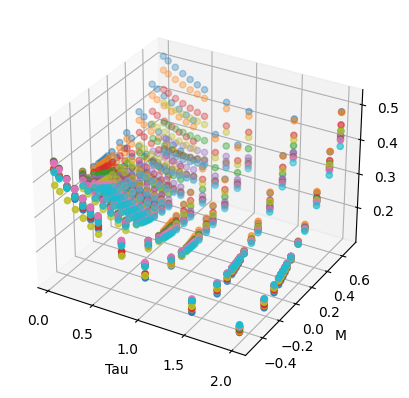

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for date in sample_dates:
    df_ = predicted_iv[predicted_iv['date'] == date]
    ax.scatter(df_['tau'], df_['m'], df_['IV'])
ax.set_xlabel('Tau')
ax.set_ylabel('M')
ax.set_zlabel('IV')
plt.show()

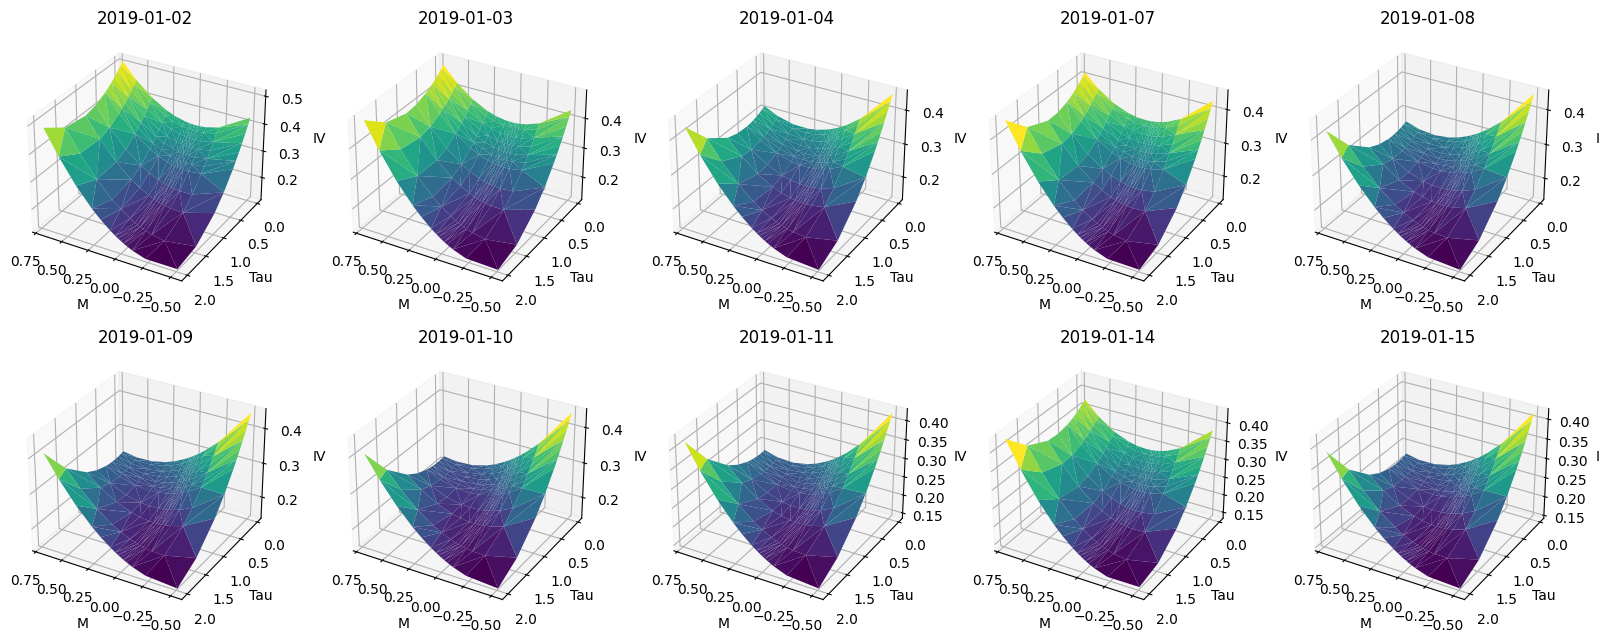

In [10]:
fig = plt.figure(figsize=(20,20))
for i, date in enumerate(sample_dates):
    df_ = predicted_iv[predicted_iv['date'] == date]
    ax = fig.add_subplot(5, 5, i+1, projection='3d')
    ax.plot_trisurf(df_['m'], df_['tau'], df_['IV'], cmap='viridis')
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_title(date)
    ax.set_xlabel('M')
    ax.set_ylabel('Tau')
    ax.set_zlabel('IV')
plt.show()